# Interactive visualization of cities and MOSAIKS clusters

We use `hvplot` to interactively visualize:
- the top-5-by-continent city footprints (`top5_by_continent.geojson`)
- the per-pixel KNN cluster assignments (`all_clusters.geojson`)

Pan/zoom on the map; cluster points are colored by `cluster_knn`.

In [1]:
%pip install hvplot jupyter_bokeh geoviews

Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
import hvplot.pandas  # noqa: F401
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

In [4]:
cities = gpd.read_file('/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/top5_by_continent.geojson')
clusters = gpd.read_file('/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/applied_clusters_knn_10.geojson')

clusters['cluster_knn'] = clusters['cluster_knn'].astype(str)

print(f'{len(cities)} city footprints, {len(clusters)} cluster points')
cities.head()

30 city footprints, 84261 cluster points


,urbanArea,UID,lat,long,Continent,top5_by_continent_OBJECTID,top5_by_continent_UrbanArea,top5_by_continent_Continent,top5_by_continent_ISO,top5_by_continent_Level_0,top5_by_continent_Level_1,top5_by_continent_Level_2,display_name,geometry
0,4366.00,41,116.395382,39.935688,Asia,16,4366,Asia,CHN,China,"Beijing, Hebei, Tianjin","Beijing, Baoding, Langfang, Tianjin",Beijing,"MULTIPOLYGON (((116.07698 39.62568, 116.07752 ..."
1,10603.90,87,113.564338,22.934839,Asia,38,10603.9,Asia,CHN,China,"Guangdong, North, Yuen Long, Macau","Dongguan, Foshan, Guangzhou, Huizhou, Jiangmen...",Guangzhou,"MULTIPOLYGON (((113.54508 23.26466, 113.54508 ..."
2,5674.21,280,120.487822,31.614716,Asia,125,5674.21,Asia,CHN,China,"Jiangsu, Shanghai","Changzhou, Nantong, Suzhou, Wuxi, Zhenjiang, S...",Jiang Su,"MULTIPOLYGON (((119.73078 31.78015, 119.73078 ..."
3,3870.61,423,121.455001,31.134216,Asia,186,3870.61,Asia,CHN,China,"Jiangsu, Shanghai","Suzhou, Shanghai",Shanghai,"MULTIPOLYGON (((121.16989 30.96816, 121.16962 ..."
4,1732.23,526,-58.537612,-34.645383,SouthAmerica,239,1732.23,SouthAmerica,ARG,Argentina,"Buenos Aires, Ciudad de Buenos Aires","Almirante Brown, Avellaneda, Berazategui, Esco...",Buenos Aires,"MULTIPOLYGON (((-58.87864 -34.63329, -58.87837..."


## Global overview

City footprints overlaid on the cluster point cloud. Hover for city metadata.

In [ ]:
cluster_points = clusters.hvplot.points(
    geo=True, color='cluster_knn', cmap='Category10', size=8, alpha=0.6,
    tiles='CartoLight',
    responsive=True, height=560,        # was frame_width=900, frame_height=500
    legend='right',
    hover_cols=['cluster_knn'],
    title='MOSAIKS KNN clusters & top-5 cities by continent',
).opts(toolbar='above')

city_polys = cities.hvplot(
    geo=True,
    color='Continent',
    cmap='Set2',
    line_color='black',
    line_width=0.5,
    alpha=0.4,
    hover_cols=['top5_by_continent_Level_0', 'display_name', 'Continent', 'urbanArea'],
)

# cluster_points * city_polys

import holoviews as hv, pathlib
pathlib.Path('../../docs/assets/figures').mkdir(parents=True, exist_ok=True)
hv.save(cluster_points * city_polys, '../../docs/assets/figures/clusters_map.html')


## Per-city view

Pick a city to zoom in on its footprint and surrounding cluster points.

In [10]:
import panel as pn
pn.extension()

city_labels = cities['top5_by_continent_Level_0'].fillna('') + ' — ' + cities['display_name'].fillna('')
city_choices = dict(zip(city_labels, cities.index))

city_select = pn.widgets.Select(name='City', options=city_choices)

@pn.depends(idx=city_select)
def city_view(idx):
    city = cities.iloc[[idx]]
    minx, miny, maxx, maxy = city.total_bounds
    pad = 0.3
    xlim = (minx - pad, maxx + pad)
    ylim = (miny - pad, maxy + pad)

    nearby = clusters.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]

    pts = nearby.hvplot.points(
        geo=True,
        color='cluster_knn',
        cmap='Category10',
        size=20,
        alpha=0.7,
        tiles='CartoLight',
        frame_width=750,
        frame_height=600,
        legend='right',
        hover_cols=['cluster_knn'],
        xlim=xlim,
        ylim=ylim,
    )
    poly = city.hvplot(
        geo=True,
        color='Continent',
        cmap='Set2',
        line_color='black',
        line_width=1.0,
        alpha=0.25,
        hover_cols=['top5_by_continent_Level_0', 'top5_by_continent_Level_2', 'urbanArea'],
    )
    return pts * poly

pn.Column(city_select, city_view)

Column
    [0] Select(name='City', options={'China — Beijing, ...}, value=0)
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

# Visualize all cities in a grid

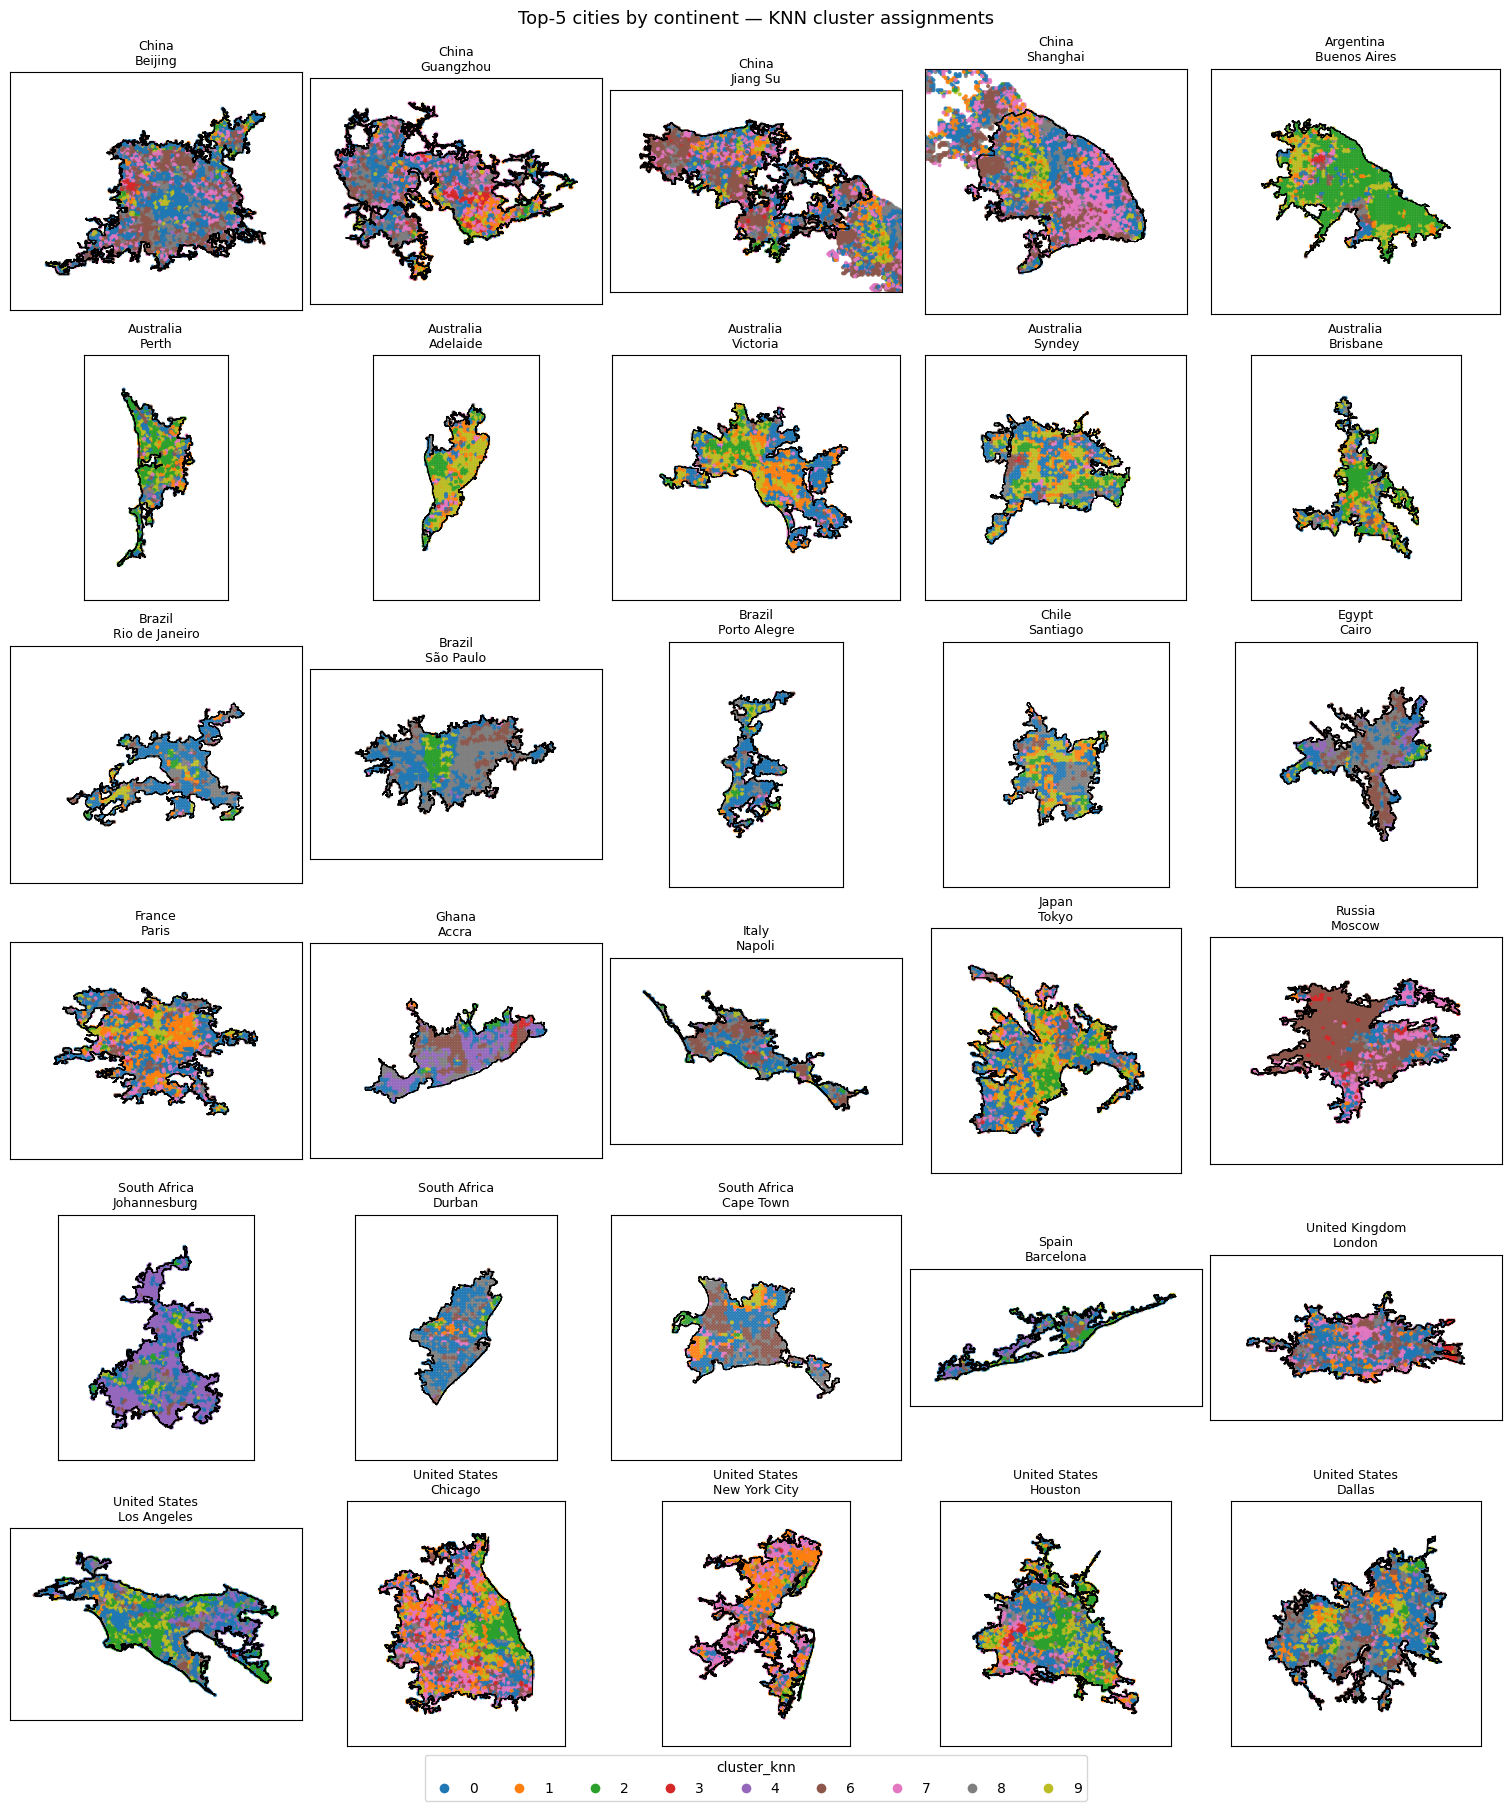

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl

cluster_ids = sorted(clusters['cluster_knn'].unique(), key=lambda x: int(x))
cmap = ListedColormap(mpl.colormaps['tab10'].colors[:len(cluster_ids)])
cluster_to_color = {c: cmap(i) for i, c in enumerate(cluster_ids)}

def first_city(s, n=18):
    s = str(s).split(',')[0].strip()
    return s if len(s) <= n else s[:n - 1] + '…'

fig, axes = plt.subplots(6, 5, figsize=(15, 18), constrained_layout=True)
pad = 0.2

for ax, (_, city) in zip(axes.flat, cities.iterrows()):
    minx, miny, maxx, maxy = city.geometry.bounds
    xlim = (minx - pad, maxx + pad)
    ylim = (miny - pad, maxy + pad)

    nearby = clusters.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
    ax.scatter(
        nearby.geometry.x, nearby.geometry.y,
        c=nearby['cluster_knn'].map(cluster_to_color),
        s=4, alpha=0.8,
    )
    gpd.GeoSeries([city.geometry]).plot(
        ax=ax, facecolor='none', edgecolor='black', linewidth=0.8,
    )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        f"{first_city(city['top5_by_continent_Level_0'], 16)}\n"
        f"{first_city(city['display_name'], 18)}",
        fontsize=9,
    )

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=cluster_to_color[c], markersize=8, label=c)
           for c in cluster_ids]
fig.legend(handles=handles, title='cluster_knn', loc='outside lower center',
           ncol=len(cluster_ids))
fig.suptitle('Top-5 cities by continent — KNN cluster assignments', fontsize=13)
plt.show()